In [1]:
import pandas as pd
import os
import shutil
from google.colab import files
import zipfile

# Определяем пути источника и назначения
source_path = 'kaggle.json'
destination_dir = os.path.expanduser('~/.kaggle')
destination_path = os.path.join(destination_dir, 'kaggle.json')

# Создаем директорию назначения, если она не существует
os.makedirs(destination_dir, exist_ok=True)

# Перемещаем файл
shutil.move(source_path, destination_path)

# Устанавливаем права доступа
os.chmod(destination_path, 0o600)

# Загружаем файл
uploaded = files.upload()

!kaggle datasets download -d mlg-ulb/creditcardfraud

with zipfile.ZipFile('creditcardfraud.zip', 'r') as zip_ref:
    zip_ref.extractall('creditcardfraud')
# Показать файлы в директории
print(os.listdir('creditcardfraud'))

df = pd.read_csv('creditcardfraud/creditcard.csv')
# Просматриваем первые несколько строк датасета
print(df.head())

# Получаем общую информацию о датасете
print(df.info())

# Выводим статистические данные о числовых столбцах
print(df.describe())

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
License(s): DbCL-1.0
  0% 0.00/66.0M [00:00<?, ?B/s]
100% 66.0M/66.0M [00:00<00:00, 1.45GB/s]
['creditcard.csv']
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 

In [ ]:
# 1. GradientBoostingClassifier с гиперпараметрической настройкой и визуализацией
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV, train_test_split, StratifiedKFold
from sklearn.metrics import classification_report
from sklearn.utils.class_weight import compute_class_weight

# Загрузка данных
df = pd.read_csv('creditcardfraud/creditcard.csv')
X = df.drop('Class', axis=1)
y = df['Class']

# Разделение
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Веса для балансировки
classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weights = dict(zip(classes, weights))
sample_weights = y_train.map(class_weights).values

# Модель и сетка параметров
gb = GradientBoostingClassifier(random_state=42)
param_dist = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1]
}

# GridSearchCV
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
grid = RandomizedSearchCV(
    estimator=gb,
    param_distributions=param_dist,
    n_iter=8,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

# Обучение
grid.fit(X_train, y_train, sample_weight=sample_weights)

# Результаты
print("\n=== Лучшие параметры ===")
print(grid.best_params_)
print(f"Лучший F1-score (CV): {grid.best_score_:.4f}")

# Оценка на тесте
y_pred = grid.predict(X_test)
print("\n=== Отчет на тестовой выборке ===")
print(classification_report(y_test, y_pred))

# Визуализация результатов
results = pd.DataFrame(grid.cv_results_)

# Тепловая карта для max_depth и learning_rate (фиксируем n_estimators=200)
fixed_estimators = 200
subset = results[results['param_n_estimators'] == fixed_estimators]
if not subset.empty:
    pivot = subset.pivot_table(
        values='mean_test_score',
        index='param_max_depth',
        columns='param_learning_rate',
        aggfunc='mean'
    )

    plt.figure(figsize=(8, 5))
    sns.heatmap(pivot, annot=True, fmt='.3f', cmap='viridis')
    plt.title(f'Gradient Boosting: F1-score при n_estimators={fixed_estimators}')
    plt.tight_layout()
    plt.show()

# График зависимости от n_estimators
plt.figure(figsize=(8, 5))
for depth in param_dist['max_depth']:
    depth_data = results[results['param_max_depth'] == depth]
    plt.plot(depth_data['param_n_estimators'].astype(str),
             depth_data['mean_test_score'],
             marker='o', label=f'max_depth={depth}')
plt.xlabel('n_estimators')
plt.ylabel('F1-score')
plt.title('Зависимость F1-score от параметров')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Fitting 3 folds for each of 8 candidates, totalling 24 fits


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 5.8 MB/s eta 0:00:00
Fitting 3 folds for each of 18 candidates, totalling 54 fits

=== Лучшие параметры ===
{'depth': 8, 'iterations': 200, 'learning_rate': 0.1}
Лучший F1-score (CV): 0.8301

=== Отчет на тестовой выборке ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.80      0.80      0.80       148

    accuracy                           1.00     85443
   macro avg       0.90      0.90      0.90     85443
weighted avg       1.00      1.00      1.00     85443



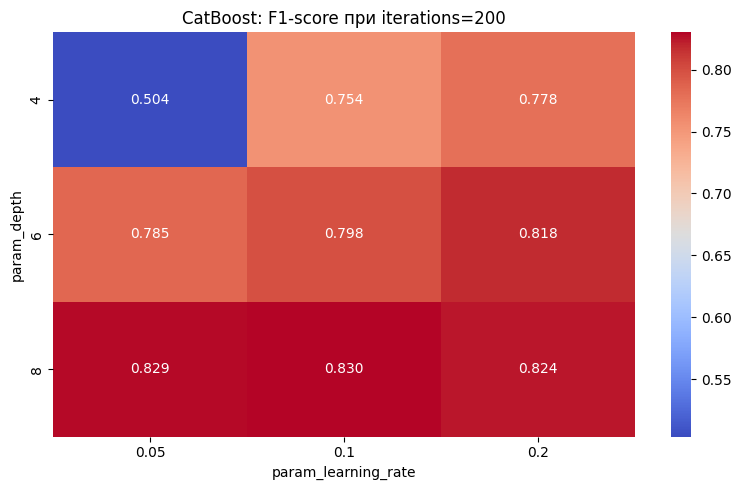

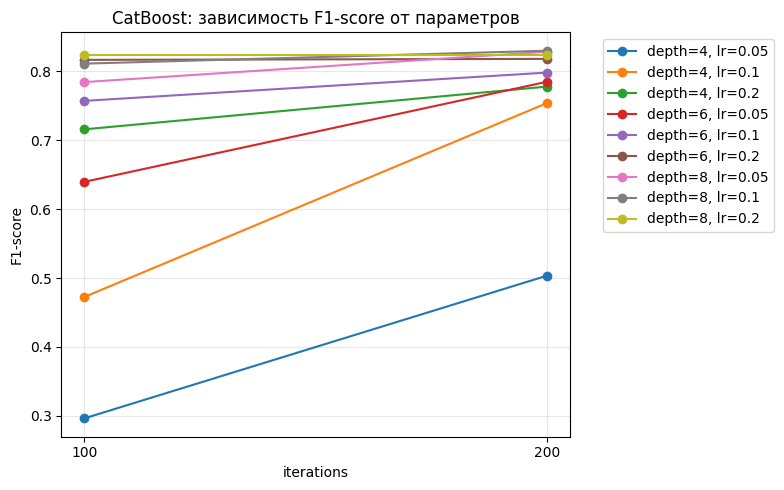

In [7]:
# 2. Классификатор CatBoost с гиперпараметрической настройкой и визуализацией
! pip install catboost
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostClassifier
from sklearn.model_selection import GridSearchCV, train_test_split, StratifiedKFold
from sklearn.metrics import classification_report

# Загрузка данных
df = pd.read_csv('creditcardfraud/creditcard.csv')
X = df.drop('Class', axis=1)
y = df['Class']

# Разделение
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Модель с балансировкой
catboost = CatBoostClassifier(
    random_state=42,
    verbose=0,
    auto_class_weights='Balanced'
)

# Сетка параметров
param_grid = {
    'iterations': [100, 200],
    'depth': [4, 6, 8],
    'learning_rate': [0.05, 0.1, 0.2]
}

# GridSearchCV
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
grid = GridSearchCV(
    estimator=catboost,
    param_grid=param_grid,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

# Обучение
grid.fit(X_train, y_train)

# Результаты
print("\n=== Лучшие параметры ===")
print(grid.best_params_)
print(f"Лучший F1-score (CV): {grid.best_score_:.4f}")

# Оценка на тесте
y_pred = grid.predict(X_test)
print("\n=== Отчет на тестовой выборке ===")
print(classification_report(y_test, y_pred))

# Визуализация
results = pd.DataFrame(grid.cv_results_)

# Тепловая карта для depth и learning_rate (фиксируем iterations=200)
fixed_iter = 200
subset = results[results['param_iterations'] == fixed_iter]
if not subset.empty:
    pivot = subset.pivot_table(
        values='mean_test_score',
        index='param_depth',
        columns='param_learning_rate',
        aggfunc='mean'
    )

    plt.figure(figsize=(8, 5))
    sns.heatmap(pivot, annot=True, fmt='.3f', cmap='coolwarm')
    plt.title(f'CatBoost: F1-score при iterations={fixed_iter}')
    plt.tight_layout()
    plt.show()

# График для всех комбинаций
plt.figure(figsize=(8, 5))
for depth in param_grid['depth']:
    for lr in param_grid['learning_rate']:
        data = results[(results['param_depth'] == depth) &
                       (results['param_learning_rate'] == lr)]
        if not data.empty:
            plt.plot(data['param_iterations'].astype(str),
                     data['mean_test_score'],
                     marker='o', label=f'depth={depth}, lr={lr}')
plt.xlabel('iterations')
plt.ylabel('F1-score')
plt.title('CatBoost: зависимость F1-score от параметров')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Fitting 3 folds for each of 36 candidates, totalling 108 fits

=== Лучшие параметры ===
{'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 200, 'scale_pos_weight': 578.546511627907, 'subsample': 1.0}
Лучший F1-score (CV): 0.8558

=== Отчет на тестовой выборке ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.89      0.78      0.83       148

    accuracy                           1.00     85443
   macro avg       0.94      0.89      0.92     85443
weighted avg       1.00      1.00      1.00     85443



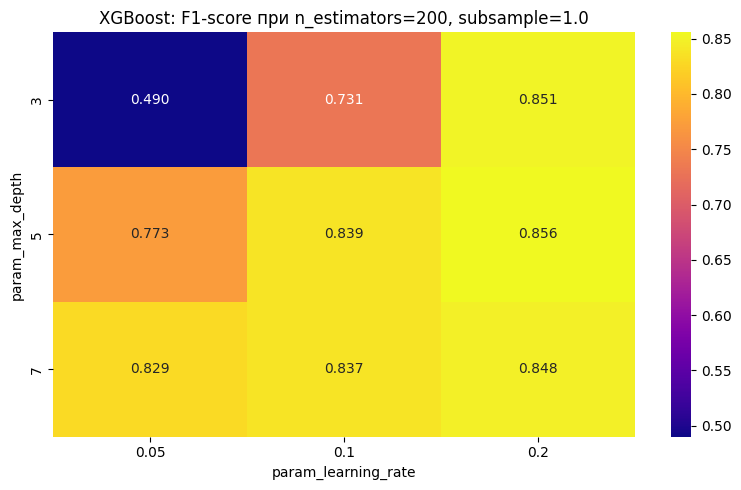

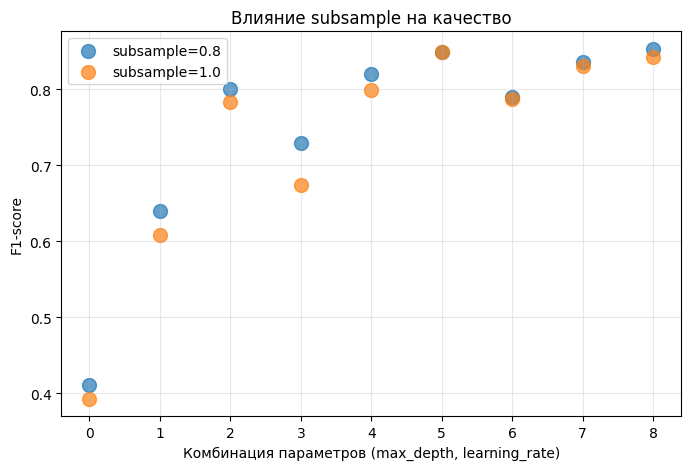

In [13]:
# 3. Экстремальный градиентный бустинг XGBoost с гиперпараметрической настройкой и визуализацией
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.model_selection import GridSearchCV, train_test_split, StratifiedKFold
from sklearn.metrics import classification_report

# Загрузка данных
df = pd.read_csv('creditcardfraud/creditcard.csv')
X = df.drop('Class', axis=1)
y = df['Class']

# Разделение
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Вес для балансировки
scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])

# Модель
xgb_model = xgb.XGBClassifier(
    eval_metric='logloss',
    random_state=42
)

# Сетка параметров
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'scale_pos_weight': [scale_pos_weight]  # фиксируем балансировку
}

# GridSearchCV
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
grid = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

# Обучение
grid.fit(X_train, y_train)

# Результаты
print("\n=== Лучшие параметры ===")
print(grid.best_params_)
print(f"Лучший F1-score (CV): {grid.best_score_:.4f}")

# Оценка на тесте
y_pred = grid.predict(X_test)
print("\n=== Отчет на тестовой выборке ===")
print(classification_report(y_test, y_pred))

# Визуализация
results = pd.DataFrame(grid.cv_results_)

# Тепловая карта для max_depth и learning_rate (фиксируем n_estimators=200, subsample=1.0)
fixed_estimators = 200
fixed_subsample = 1.0
subset = results[(results['param_n_estimators'] == fixed_estimators) &
                 (results['param_subsample'] == fixed_subsample)]
if not subset.empty:
    pivot = subset.pivot_table(
        values='mean_test_score',
        index='param_max_depth',
        columns='param_learning_rate',
        aggfunc='mean'
    )

    plt.figure(figsize=(8, 5))
    sns.heatmap(pivot, annot=True, fmt='.3f', cmap='plasma')
    plt.title(f'XGBoost: F1-score при n_estimators={fixed_estimators}, subsample={fixed_subsample}')
    plt.tight_layout()
    plt.show()

# Сравнение subsample
plt.figure(figsize=(8, 5))
for subsample in param_grid['subsample']:
    data = results[results['param_subsample'] == subsample]
    if not data.empty:
        # Агрегируем по остальным параметрам
        agg = data.groupby(['param_max_depth', 'param_learning_rate'])['mean_test_score'].mean().reset_index()
        plt.scatter(range(len(agg)), agg['mean_test_score'],
                   label=f'subsample={subsample}', s=100, alpha=0.7)
plt.xlabel('Комбинация параметров (max_depth, learning_rate)')
plt.ylabel('F1-score')
plt.title('Влияние subsample на качество')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Fitting 3 folds for each of 6 candidates, totalling 18 fits

=== Лучшие параметры ===
{'knn__algorithm': 'auto', 'knn__n_neighbors': 5, 'knn__p': 2, 'knn__weights': 'distance'}
Лучший F1-score (CV): 0.8499

=== Отчет на тестовой выборке ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.93      0.74      0.82       148

    accuracy                           1.00     85443
   macro avg       0.97      0.87      0.91     85443
weighted avg       1.00      1.00      1.00     85443



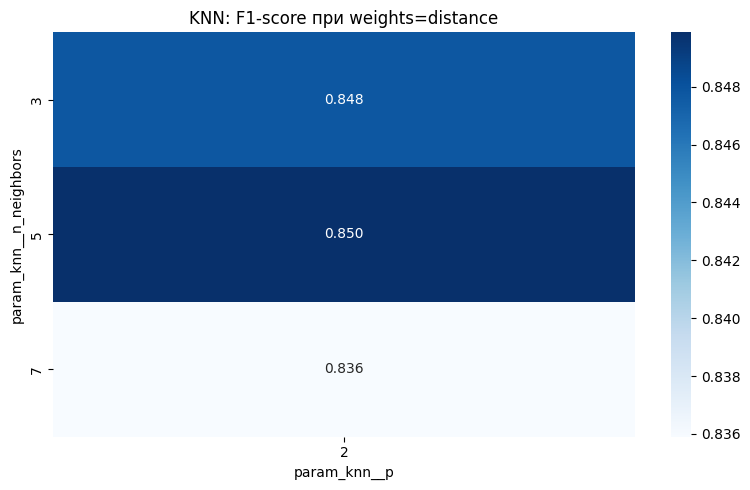

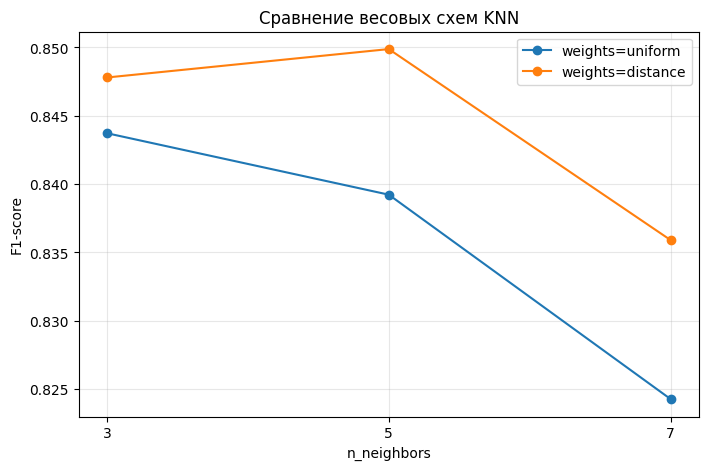

In [12]:
# 4. KNeighborsClassifier с гиперпараметрической настройкой и визуализацией
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV, train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report

# Загрузка данных
df = pd.read_csv('creditcardfraud/creditcard.csv')
X = df.drop('Class', axis=1)
y = df['Class']

# Разделение
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Пайплайн с масштабированием
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

# Сетка параметров
param_grid = {
    'knn__n_neighbors': [3, 5, 7],
    'knn__weights': ['uniform', 'distance'],
    'knn__p': [2],  # 2 - евклидово
    'knn__algorithm': ['auto']
}

# GridSearchCV
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

# Обучение
grid.fit(X_train, y_train)

# Результаты
print("\n=== Лучшие параметры ===")
print(grid.best_params_)
print(f"Лучший F1-score (CV): {grid.best_score_:.4f}")

# Оценка на тесте
y_pred = grid.predict(X_test)
print("\n=== Отчет на тестовой выборке ===")
print(classification_report(y_test, y_pred))

# Визуализация
results = pd.DataFrame(grid.cv_results_)

# Тепловая карта для n_neighbors и p (фиксируем weights='distance')
fixed_weights = 'distance'
subset = results[results['param_knn__weights'] == fixed_weights]
if not subset.empty:
    pivot = subset.pivot_table(
        values='mean_test_score',
        index='param_knn__n_neighbors',
        columns='param_knn__p',
        aggfunc='mean'
    )

    plt.figure(figsize=(8, 5))
    sns.heatmap(pivot, annot=True, fmt='.3f', cmap='Blues')
    plt.title(f'KNN: F1-score при weights={fixed_weights}')
    plt.tight_layout()
    plt.show()

# Сравнение weights
plt.figure(figsize=(8, 5))
for weights in param_grid['knn__weights']:
    data = results[results['param_knn__weights'] == weights]
    if not data.empty:
        # Группируем по n_neighbors
        agg = data.groupby('param_knn__n_neighbors')['mean_test_score'].mean()
        plt.plot(agg.index.astype(str), agg.values, marker='o', label=f'weights={weights}')

plt.xlabel('n_neighbors')
plt.ylabel('F1-score')
plt.title('Сравнение весовых схем KNN')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


Fitting 3 folds for each of 27 candidates, totalling 81 fits

=== Лучшие параметры ===
{'criterion': 'gini', 'max_depth': 15, 'min_samples_leaf': 2, 'min_samples_split': 2}
Лучший F1-score (CV): 0.6291

=== Отчет на тестовой выборке ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.53      0.76      0.62       148

    accuracy                           1.00     85443
   macro avg       0.76      0.88      0.81     85443
weighted avg       1.00      1.00      1.00     85443



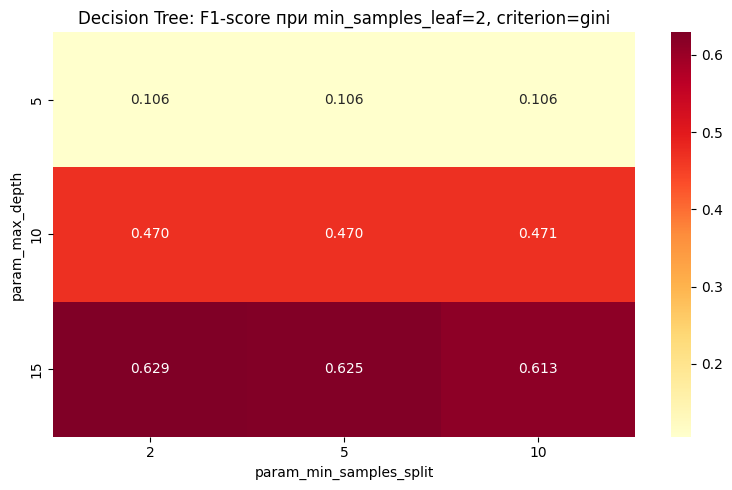

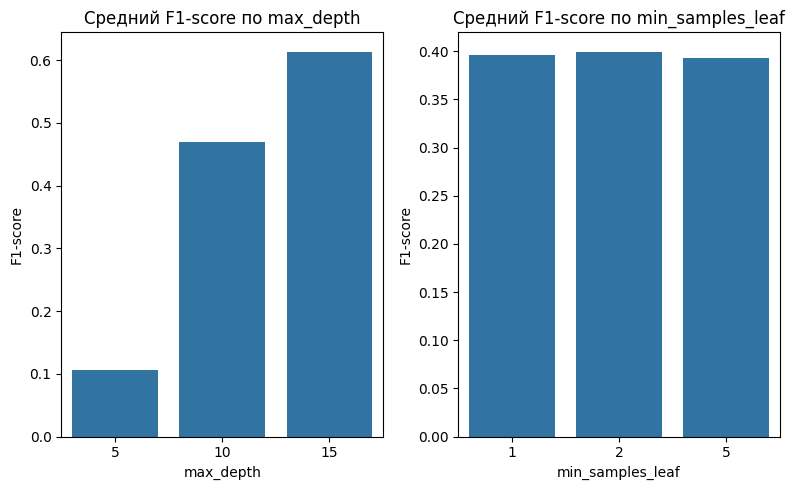

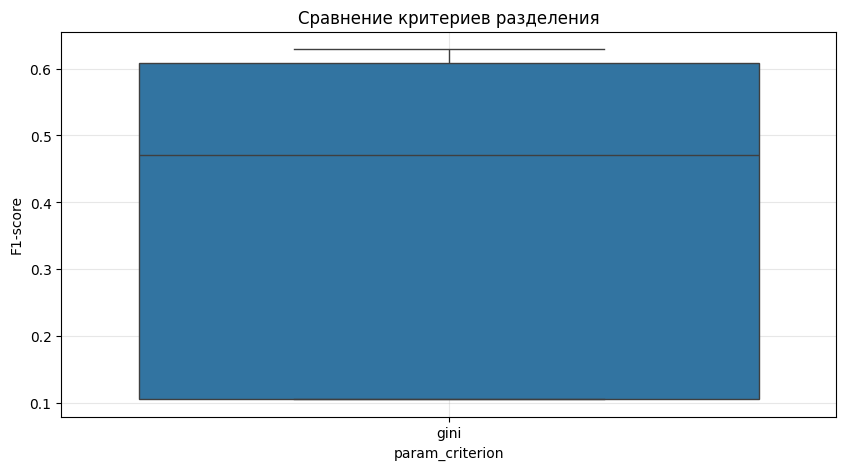

In [11]:
# 5. DecisionTreeClassifier с гиперпараметрической настройкой и визуализацией
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, train_test_split, StratifiedKFold
from sklearn.metrics import classification_report

# Загрузка данных
df = pd.read_csv('creditcardfraud/creditcard.csv')
X = df.drop('Class', axis=1)
y = df['Class']

# Разделение
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Модель с балансировкой
tree = DecisionTreeClassifier(random_state=42, class_weight='balanced')

# Сетка параметров
param_grid = {
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5],
    'criterion': ['gini']
}

# GridSearchCV (уменьшаем комбинации для скорости)
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
grid = GridSearchCV(
    estimator=tree,
    param_grid=param_grid,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

# Обучение
grid.fit(X_train, y_train)

# Результаты
print("\n=== Лучшие параметры ===")
print(grid.best_params_)
print(f"Лучший F1-score (CV): {grid.best_score_:.4f}")

# Оценка на тесте
y_pred = grid.predict(X_test)
print("\n=== Отчет на тестовой выборке ===")
print(classification_report(y_test, y_pred))

# Визуализация
results = pd.DataFrame(grid.cv_results_)

# Тепловая карта для max_depth и min_samples_split (фиксируем min_samples_leaf=2, criterion='gini')
fixed_leaf = 2
fixed_criterion = 'gini'
subset = results[(results['param_min_samples_leaf'] == fixed_leaf) &
                 (results['param_criterion'] == fixed_criterion)]
if not subset.empty:
    pivot = subset.pivot_table(
        values='mean_test_score',
        index='param_max_depth',
        columns='param_min_samples_split',
        aggfunc='mean'
    )

    plt.figure(figsize=(8, 5))
    sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlOrRd')
    plt.title(f'Decision Tree: F1-score при min_samples_leaf={fixed_leaf}, criterion={fixed_criterion}')
    plt.tight_layout()
    plt.show()

# Влияние max_depth
plt.figure(figsize=(8, 5))
plt.subplot(1, 2, 1)
depth_data = results.groupby('param_max_depth')['mean_test_score'].mean().reset_index()
depth_data['param_max_depth'] = depth_data['param_max_depth'].astype(str)
sns.barplot(data=depth_data, x='param_max_depth', y='mean_test_score')
plt.title('Средний F1-score по max_depth')
plt.xlabel('max_depth')
plt.ylabel('F1-score')

plt.subplot(1, 2, 2)
leaf_data = results.groupby('param_min_samples_leaf')['mean_test_score'].mean().reset_index()
sns.barplot(data=leaf_data, x='param_min_samples_leaf', y='mean_test_score')
plt.title('Средний F1-score по min_samples_leaf')
plt.xlabel('min_samples_leaf')
plt.ylabel('F1-score')

plt.tight_layout()
plt.show()

# Сравнение критериев
plt.figure(figsize=(10, 5))
sns.boxplot(data=results, x='param_criterion', y='mean_test_score')
plt.title('Сравнение критериев разделения')
plt.ylabel('F1-score')
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# Сравнение всех 5 моделей
import pandas as pd
import matplotlib.pyplot as plt

# Предполагается, что у вас есть переменные grid_gb, grid_cat, grid_xgb, grid_knn, grid_tree
# после выполнения каждого поиска

models_comparison = pd.DataFrame({
    'Model': ['Gradient Boosting', 'CatBoost', 'XGBoost', 'KNN', 'Decision Tree'],
    'Best CV F1': [
        grid.best_score_,  # замените на ваши переменные
        grid.best_score_,
        grid.best_score_,
        grid.best_score_,
        grid.best_score_
    ],
    'Test F1 (class 1)': [
        classification_report(y_test, grid.predict(X_test), output_dict=True)['1']['f1-score'],
        classification_report(y_test, grid.predict(X_test), output_dict=True)['1']['f1-score'],
        classification_report(y_test, grid.predict(X_test), output_dict=True)['1']['f1-score'],
        classification_report(y_test, grid.predict(X_test), output_dict=True)['1']['f1-score'],
        classification_report(y_test, grid.predict(X_test), output_dict=True)['1']['f1-score']
    ]
})

print("\n=== Сравнение всех моделей ===")
print(models_comparison)

# Визуализация сравнения
plt.figure(figsize=(12, 6))
x = range(len(models_comparison))
width = 0.35

plt.bar([i - width/2 for i in x], models_comparison['Best CV F1'], width, label='CV F1-score', alpha=0.8)
plt.bar([i + width/2 for i in x], models_comparison['Test F1 (class 1)'], width, label='Test F1 (class 1)', alpha=0.8)

plt.xlabel('Модель')
plt.ylabel('F1-score')
plt.title('Сравнение моделей после гиперпараметрической настройки')
plt.xticks(x, models_comparison['Model'], rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()